In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/content/health - Sheet4.csv')
df

,Fever,Cough,Headache,Bodypain,Flu
0,Yes,Yes,High,High,Yes
1,No,Yes,Low,Low,No
2,Yes,No,Medium,Medium,Yes
3,No,No,Low,Low,No
4,No,Yes,Medium,Low,No
5,Yes,No,Medium,Medium,Yes
6,No,No,Low,Low,No
7,Yes,No,Medium,Medium,Yes
8,Yes,Yes,High,High,Yes
9,No,Yes,Medium,Low,No


In [4]:
input=df.drop('Flu',axis='columns')
target=df['Flu']
target

,Flu
0,Yes
1,No
2,Yes
3,No
4,No
5,Yes
6,No
7,Yes
8,Yes
9,No


In [5]:
le_Fever=LabelEncoder()
le_Cough=LabelEncoder()
le_Headache=LabelEncoder()
le_Bodypain=LabelEncoder()

In [6]:
input['Fever_n']=le_Fever.fit_transform(input['Fever'])
input['Cough_n']=le_Cough.fit_transform(input['Cough'])
input['Headache_n']=le_Headache.fit_transform(input['Headache'])
input['Bodypain_n']=le_Bodypain.fit_transform(input['Bodypain'])

In [7]:
input_n=input.drop(['Fever','Cough','Headache','Bodypain'],axis='columns')
input_n

,Fever_n,Cough_n,Headache_n,Bodypain_n
0,1,1,0,0
1,0,1,1,1
2,1,0,2,2
3,0,0,1,1
4,0,1,2,1
5,1,0,2,2
6,0,0,1,1
7,1,0,2,2
8,1,1,0,0
9,0,1,2,1


In [8]:
model=tree.DecisionTreeClassifier()
model.fit(input_n,target)

DecisionTreeClassifier()

In [9]:
#prediction=model.predict([[0,0,0,0]]) -> Yes
#prediction=model.predict([[1,1,1,1]]) -> No
#prediction=model.predict([[2,2,2,2]]) -> No
prediction=model.predict([[0,0,0,1]])
print("Prediction",prediction)

Prediction ['No']


In [10]:
accuracy=model.score(input_n,target)
print("Accuracy",accuracy)

Accuracy 1.0


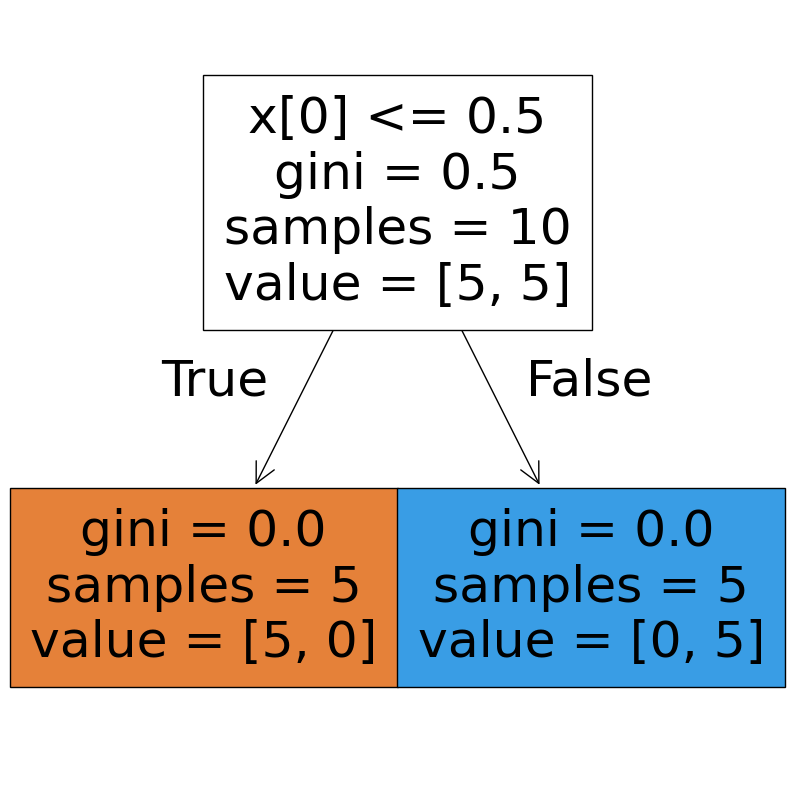

In [11]:
plt.figure(figsize=(10,10))
tree.plot_tree(model,filled=True)
plt.show()